#### Imports

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle

plt.style.use('seaborn-v0_8-muted')
pd.set_option('display.max_columns', None)

print("Supply Chain Infrastructure Engine Loaded.")

Supply Chain Infrastructure Engine Loaded.


#### Modeling the Jimma-Djibouti Corridor

In [2]:
# Real-World Nodes
nodes_data = [
    {"id": "Gera_Smallholders", "type": "Origin", "lat": 7.70, "lon": 36.25, "name": "Gera Woreda Farms"},
    {"id": "Telila_WS", "type": "Washing_Station", "lat": 7.72, "lon": 36.30, "name": "Telila Washing Station"},
    {"id": "Jimma_Hub", "type": "Collector", "lat": 7.67, "lon": 36.83, "name": "Jimma Aggregation Center"},
    {"id": "Kality_Dry_Mill", "type": "Processor", "lat": 8.92, "lon": 38.78, "name": "Kality Industrial Mill"},
    {"id": "ECX_Adama", "type": "Regulatory", "lat": 8.54, "lon": 39.27, "name": "ECX Adama Warehouse"},
    {"id": "SGTD_Doraleh", "type": "Terminal", "lat": 11.59, "lon": 43.10, "name": "SGTD Doraleh Port (Djibouti)"}
]

nodes_df = pd.DataFrame(nodes_data)
print("Real-world Infrastructure Mapped.")
display(nodes_df)

Real-world Infrastructure Mapped.


,id,type,lat,lon,name
0,Gera_Smallholders,Origin,7.70,36.25,Gera Woreda Farms
1,Telila_WS,Washing_Station,7.72,36.30,Telila Washing Station
2,Jimma_Hub,Collector,7.67,36.83,Jimma Aggregation Center
3,Kality_Dry_Mill,Processor,8.92,38.78,Kality Industrial Mill
4,ECX_Adama,Regulatory,8.54,39.27,ECX Adama Warehouse
5,SGTD_Doraleh,Terminal,11.59,43.10,SGTD Doraleh Port (Djibouti)


#### The Real Value Leak Parameters

In [3]:
# (Source, Target, Distance_km, Cost_USD_kg, Loss_Rate_pct, Time_Hours)
edge_definitions = [
    ("Gera_Smallholders", "Telila_WS", 8, 0.05, 0.015, 1),
    ("Telila_WS", "Jimma_Hub", 45, 0.12, 0.005, 4),
    ("Jimma_Hub", "Kality_Dry_Mill", 355, 0.48, 0.020, 18),
    ("Kality_Dry_Mill", "ECX_Adama", 92, 0.18, 0.005, 6),
    ("ECX_Adama", "SGTD_Doraleh", 815, 0.82, 0.012, 48)
]

# Initialize Directed Graph
G = nx.DiGraph()

# Add nodes with metadata
for _, row in nodes_df.iterrows():
    G.add_node(row['id'], **row.to_dict())

# Add edges with weights
for u, v, dist, cost, loss, time in edge_definitions:
    G.add_edge(u, v, distance_km=dist, cost_usd=cost, loss_rate=loss, time_hr=time)

print(f"Supply Chain Graph Initialized with {G.number_of_edges()} real-world links.")

Supply Chain Graph Initialized with 5 real-world links.


#### Infrastructure Visualization

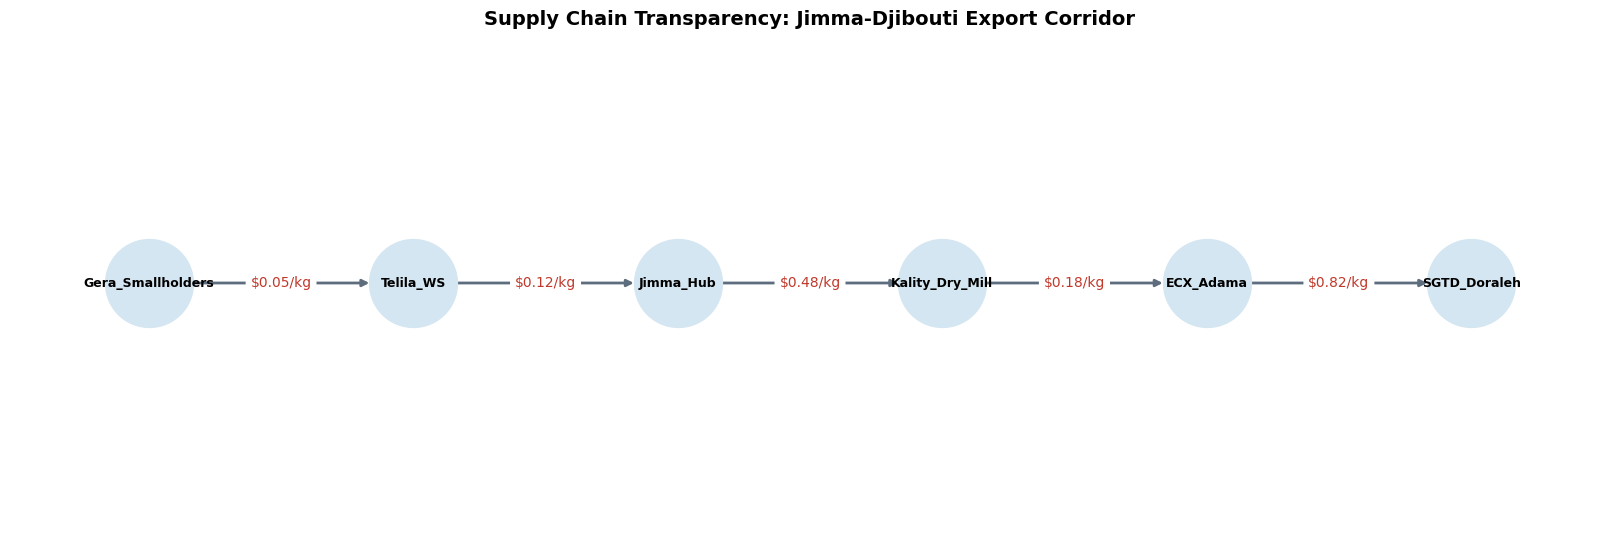

In [4]:
# linear layout for the corridor
pos = {node: (i, 1) for i, node in enumerate(nodes_df['id'])}

plt.figure(figsize=(16, 5))
nx.draw(G, pos, with_labels=True, node_size=4000, node_color='#D4E6F1', 
        font_size=9, font_weight='bold', edge_color='#5D6D7E', arrows=True, width=2)

# Edge Labels for Cost
edge_labels = {(u, v): f"${d['cost_usd']}/kg" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='#C0392B', font_size=10)

plt.title("Supply Chain Transparency: Jimma-Djibouti Export Corridor", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

#### Saving the Verified Topology

In [5]:
os.makedirs('../data/processed', exist_ok=True)

with open('../data/processed/verified_logistics_graph.pkl', 'wb') as f:
    pickle.dump(G, f)

print("Real-world infrastructure saved.")

Real-world infrastructure saved.
